# **Exploratory Data Analysis of the MOEX Dataset**

TODO

## **Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_palette(sns.color_palette('CMRmap'))
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10


DATA_PATH = Path('/kaggle/input/datasets/rinapetuhova/moex-2010-2026/moex_dataset')
PROCESSED_PATH = Path('/kaggle/working/moex_processed')
PROCESSED_PATH.mkdir(exist_ok=True)

market_history = pd.read_csv(DATA_PATH / 'market_history.csv')
security_descriptions = pd.read_csv(DATA_PATH / 'security_descriptions.csv')
dividends = pd.read_csv(DATA_PATH / 'dividends.csv', sep=';')

market_history['TRADEDATE'] = pd.to_datetime(market_history['TRADEDATE'])
dividends['registryclosedate'] = pd.to_datetime(dividends['registryclosedate'])

print('=== MARKET HISTORY ===')
print(f'Shape: {market_history.shape}')
print(f'Date range: {market_history["TRADEDATE"].min()} to {market_history["TRADEDATE"].max()}')
print(f'Securities: {market_history["SECID"].nunique()}')

=== MARKET HISTORY ===
Shape: (1086140, 24)
Date range: 2010-02-01 00:00:00 to 2026-01-30 00:00:00
Securities: 249


## **Data Quality Check**

In [2]:
print('=== QUALITY CHECK: MARKET HISTORY ===')
missing = market_history.isnull().sum()
missing_pct = (missing / len(market_history) * 100).round(2)
print('Missing values in key columns:')
for col in ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME', 'VALUE']:
    print(f'  {col}: {missing_pct[col]}%')

print('\n=== BOARDID DISTRIBUTION ===')
print(market_history['BOARDID'].value_counts().head(10))

=== QUALITY CHECK: MARKET HISTORY ===
Missing values in key columns:
  OPEN: 15.08%
  HIGH: 15.07%
  LOW: 15.07%
  CLOSE: 15.08%
  VOLUME: 0.0%
  VALUE: 0.0%

=== BOARDID DISTRIBUTION ===
BOARDID
TQBR    655236
SMAL    196282
EQNE     77796
EQDP     45430
EQNL     30500
TQNE     23152
EQBR     17322
SPEQ     12659
EQBS      7596
TQNL      7459
Name: count, dtype: int64


## **Temporal Range and Data Sufficiency Analysis**

=== HISTORY SUFFICIENCY ===
Securities with >3 years: 238
Securities with >2 years: 249
Securities with >1 year: 249


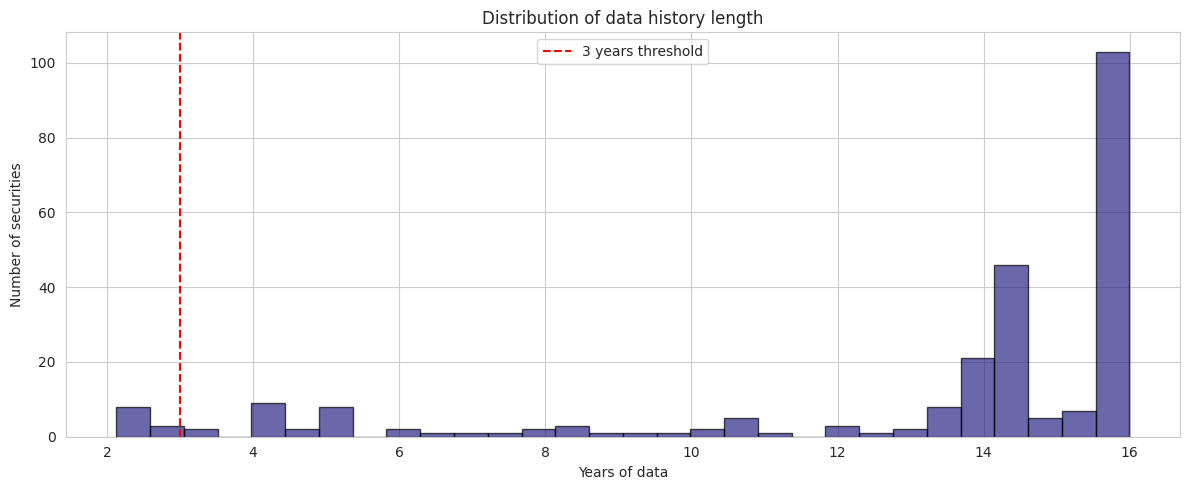

In [3]:
sec_dates = market_history.groupby('SECID')['TRADEDATE'].agg(['min', 'max'])
sec_dates['years_of_data'] = (sec_dates['max'] - sec_dates['min']).dt.days / 365.25

print('=== HISTORY SUFFICIENCY ===')
print(f'Securities with >3 years: {(sec_dates["years_of_data"] > 3).sum()}')
print(f'Securities with >2 years: {(sec_dates["years_of_data"] > 2).sum()}')
print(f'Securities with >1 year: {(sec_dates["years_of_data"] > 1).sum()}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(sec_dates['years_of_data'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(x=3, color='red', linestyle='--', label='3 years threshold')
ax.set_xlabel('Years of data')
ax.set_ylabel('Number of securities')
ax.set_title('Distribution of data history length')
ax.legend()
plt.tight_layout()
plt.show()

## **Liquidity Analysis**

=== LIQUIDITY ===
Securities with avg_daily_value > 1M RUB: 216
Securities with avg_daily_value > 100K RUB: 243


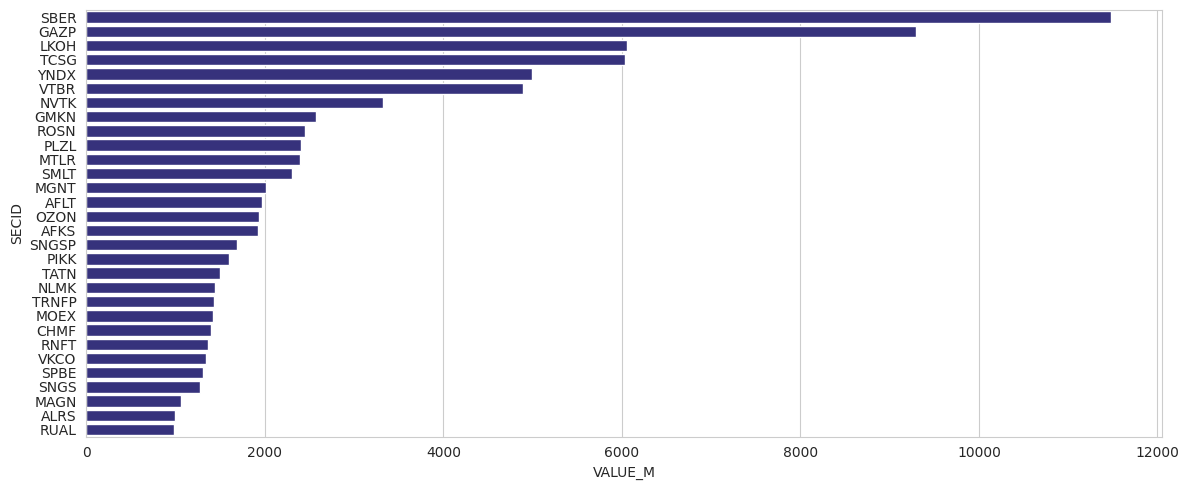

In [4]:
recent_data = market_history[
    (market_history['BOARDID'] == 'TQBR') & 
    (market_history['TRADEDATE'] >= '2024-01-01')
]

liquidity = recent_data.groupby('SECID')['VALUE'].mean().sort_values(ascending=False)

print('=== LIQUIDITY ===')
print(f'Securities with avg_daily_value > 1M RUB: {(liquidity > 1_000_000).sum()}')
print(f'Securities with avg_daily_value > 100K RUB: {(liquidity > 100_000).sum()}')

top_liq = liquidity.head(30).reset_index()
top_liq.columns = ['SECID', 'VALUE']
top_liq['VALUE_M'] = top_liq['VALUE'] / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_liq, y='SECID', x='VALUE_M', ax=ax)
plt.tight_layout()
plt.show()

## **Dividends and Delisting Analysis**

In [5]:
sec_dates = market_history[market_history['BOARDID'] == 'TQBR'].groupby('SECID')['TRADEDATE'].agg(['min', 'max'])
sec_dates['is_active'] = sec_dates['max'] >= '2025-01-01'

print('=== DELISTING ===')
print(f'Active securities: {sec_dates["is_active"].sum()}')
print(f'Delisted: {(~sec_dates["is_active"]).sum()}')

print('\n=== DIVIDENDS ===')
dividends.columns = ['SECID', 'isin', 'registryclosedate', 'value', 'currencyid']
dividends['year'] = dividends['registryclosedate'].dt.year
div_by_year = dividends.groupby('year')['SECID'].nunique()
print(f'Securities with dividends: {dividends["SECID"].nunique()}')
print('Dividends by year:')
print(div_by_year)

=== DELISTING ===
Active securities: 239
Delisted: 10

=== DIVIDENDS ===
Securities with dividends: 163
Dividends by year:
year
2013     15
2014     35
2015     35
2016     36
2017     39
2018     76
2019    128
2020    114
2021    108
2022     95
2023    112
2024    121
2025     97
Name: SECID, dtype: int64


## **Data Cleaning and Preprocessing**

In [6]:
df = market_history.copy()

board_priority = {'TQBR': 1, 'SMAL': 2, 'EQNE': 3, 'EQDP': 4, 'EQNL': 5}
df['board_priority'] = df['BOARDID'].map(board_priority).fillna(99)

df = df.sort_values(['SECID', 'TRADEDATE', 'board_priority'])
df = df.drop_duplicates(subset=['SECID', 'TRADEDATE'], keep='first')
df = df.drop(columns=['board_priority'])

print(f'After deduplication: {len(df)} rows')

key_cols = ['TRADEDATE', 'SECID', 'OPEN', 'HIGH', 'LOW', 'CLOSE']
df = df.dropna(subset=key_cols)
print(f'After dropping NaN in OHLC: {len(df)} rows')

df = df.sort_values(['SECID', 'TRADEDATE']).reset_index(drop=True)

df.to_csv(PROCESSED_PATH / 'market_history_corrected.csv', index=False)
print(f'\nSaved: market_history_corrected.csv')

After deduplication: 822905 rows
After dropping NaN in OHLC: 720947 rows

Saved: market_history_corrected.csv


## **Technical Features Calculation (momentum, volatility, max_drawdown)**

In [7]:
df = pd.read_csv(PROCESSED_PATH / 'market_history_corrected.csv', parse_dates=['TRADEDATE'])

def calculate_momentum(df, periods):
    for period in periods:
        col_name = f'momentum_{period}m'
        df[col_name] = df.groupby('SECID')['CLOSE'].transform(
            lambda x: x / x.shift(period * 21) - 1
        )
    return df

def calculate_volatility(df, periods):
    df = df.sort_values(['SECID', 'TRADEDATE'])
    df['daily_return'] = df.groupby('SECID')['CLOSE'].pct_change()
    for period in periods:
        col_name = f'volatility_{period}m'
        trading_days = period * 21
        df[col_name] = df.groupby('SECID')['daily_return'].transform(
            lambda x: x.rolling(window=trading_days, min_periods=trading_days).std() * np.sqrt(252)
        )
    df = df.drop(columns=['daily_return'], errors='ignore')
    return df

def calculate_max_drawdown(df, periods):
    df = df.sort_values(['SECID', 'TRADEDATE'])
    for period in periods:
        col_name = f'max_drawdown_{period}m'
        trading_days = period * 21
        def rolling_max_dd(group):
            prices = group['CLOSE']
            rolling_max = prices.rolling(window=trading_days, min_periods=trading_days).max()
            drawdown = (prices - rolling_max) / rolling_max
            return drawdown.rolling(window=trading_days, min_periods=trading_days).min()
        df[col_name] = df.groupby('SECID', group_keys=False).apply(rolling_max_dd)
    return df

print('Calculating momentum...')
df = calculate_momentum(df, [6, 12, 24, 36])

print('Calculating volatility...')
df = calculate_volatility(df, [6, 12, 24, 36])

print('Calculating max_drawdown...')
df = calculate_max_drawdown(df, [6, 12, 24, 36])

print(f'Shape after technical features: {df.shape}')

Calculating momentum...
Calculating volatility...
Calculating max_drawdown...
Shape after technical features: (720947, 36)


## **Financial Features Calculation (avg_value, relative_strength, beta)**

In [8]:
def calculate_avg_value(df, periods):
    for period in periods:
        col_name = f'avg_value_{period}m'
        trading_days = period * 21
        df[col_name] = df.groupby('SECID')['VALUE'].transform(
            lambda x: x.rolling(window=trading_days, min_periods=trading_days).mean()
        )
    return df

def calculate_relative_strength(df, index_ticker='MOEX'):
    index_data = df[df['SECID'] == index_ticker][['TRADEDATE', 'CLOSE']].copy()
    index_data.columns = ['TRADEDATE', 'INDEX_CLOSE']
    df = df.merge(index_data, on='TRADEDATE', how='left')
    df['relative_strength_12m'] = df['CLOSE'] / df['INDEX_CLOSE']
    df = df.drop(columns=['INDEX_CLOSE'])
    return df

def calculate_excess_return(df, index_ticker='MOEX'):
    df = df.sort_values(['SECID', 'TRADEDATE'])
    index_data = df[df['SECID'] == index_ticker][['TRADEDATE', 'CLOSE']].copy()
    index_data['INDEX_RETURN'] = index_data['CLOSE'].pct_change()
    index_data = index_data[['TRADEDATE', 'INDEX_RETURN']]
    df = df.merge(index_data, on='TRADEDATE', how='left')
    df['daily_return'] = df.groupby('SECID')['CLOSE'].pct_change()
    df['excess_daily_return'] = df['daily_return'] - df['INDEX_RETURN']
    trading_days = 6 * 21
    df['excess_return_6m'] = df.groupby('SECID')['excess_daily_return'].transform(
        lambda x: (1 + x).rolling(window=trading_days, min_periods=trading_days).apply(lambda y: y.prod() - 1, raw=True)
    )
    df = df.drop(columns=['INDEX_RETURN', 'daily_return', 'excess_daily_return'], errors='ignore')
    return df

def calculate_beta(df, index_ticker='MOEX'):
    df = df.sort_values(['SECID', 'TRADEDATE'])
    index_data = df[df['SECID'] == index_ticker][['TRADEDATE', 'CLOSE']].copy()
    index_data['INDEX_RETURN'] = index_data['CLOSE'].pct_change()
    index_data = index_data[['TRADEDATE', 'INDEX_RETURN']]
    df = df.merge(index_data, on='TRADEDATE', how='left')
    df['daily_return'] = df.groupby('SECID')['CLOSE'].pct_change()
    def rolling_beta(group):
        trading_days = 12 * 21
        cov = group['daily_return'].rolling(window=trading_days, min_periods=trading_days).cov(group['INDEX_RETURN'])
        var = group['INDEX_RETURN'].rolling(window=trading_days, min_periods=trading_days).var()
        return cov / var
    df['beta_12m'] = df.groupby('SECID', group_keys=False).apply(rolling_beta)
    df = df.drop(columns=['INDEX_RETURN', 'daily_return'], errors='ignore')
    return df

print('Calculating avg_value...')
df = calculate_avg_value(df, [6, 12, 36])

print('Calculating relative_strength...')
df = calculate_relative_strength(df, 'MOEX')

print('Calculating excess_return...')
df = calculate_excess_return(df, 'MOEX')

print('Calculating beta...')
df = calculate_beta(df, 'MOEX')

print(f'Shape after financial features: {df.shape}')

Calculating avg_value...
Calculating relative_strength...
Calculating excess_return...
Calculating beta...
Shape after financial features: (720947, 42)


## **Dividend Features Calculation**

In [9]:
dividends = pd.read_csv(DATA_PATH / 'dividends.csv', sep=';')
dividends.columns = ['SECID', 'isin', 'registryclosedate', 'value', 'currencyid']
dividends['registryclosedate'] = pd.to_datetime(dividends['registryclosedate'])
dividends = dividends[['SECID', 'registryclosedate', 'value']].dropna()

def calculate_dividend_features(df, dividends):
    df = df.copy()
    
    div_events = dividends.copy()
    div_events['year_month'] = div_events['registryclosedate'].dt.to_period('M')
    div_monthly = div_events.groupby(['SECID', 'year_month'])['value'].sum().reset_index()
    
    df['year_month'] = df['TRADEDATE'].dt.to_period('M')
    
    results = []
    for sec in df['SECID'].unique():
        sec_df = df[df['SECID'] == sec].copy()
        sec_div = div_monthly[div_monthly['SECID'] == sec].copy()
        
        if sec_div.empty:
            sec_df['dividend_yield_12m'] = np.nan
            sec_df['dividend_yield_3y_avg'] = np.nan
            sec_df['dividend_consistency_3y'] = 0
        else:
            for idx, row in sec_df.iterrows():
                current_ym = row['year_month']
                price = row['CLOSE']
                
                if pd.isna(price) or price <= 0:
                    continue
                
                start_ym_12m = (current_ym.to_timestamp() - pd.DateOffset(months=12)).to_period('M')
                start_ym_3y = (current_ym.to_timestamp() - pd.DateOffset(years=3)).to_period('M')
                
                div_12m = sec_div[(sec_div['year_month'] > start_ym_12m) & (sec_div['year_month'] <= current_ym)]['value'].sum()
                
                div_3y = sec_div[(sec_div['year_month'] > start_ym_3y) & (sec_div['year_month'] <= current_ym)]['value'].sum()
                years_with_div = sec_div[(sec_div['year_month'] > start_ym_3y) & (sec_div['year_month'] <= current_ym)]['year_month'].dt.year.nunique()
                
                results.append({
                    'SECID': sec,
                    'TRADEDATE': row['TRADEDATE'],
                    'dividend_yield_12m': div_12m / price if price > 0 else np.nan,
                    'dividend_yield_3y_avg': div_3y / price / 3 if price > 0 else np.nan,
                    'dividend_consistency_3y': min(years_with_div, 3) / 3
                })
    
    div_features = pd.DataFrame(results)
    df = df.drop(columns=['year_month'], errors='ignore')
    df = df.merge(div_features, on=['SECID', 'TRADEDATE'], how='left')
    
    return df

print('Calculating dividend features...')
df = calculate_dividend_features(df, dividends)

print(f'Shape after dividend features: {df.shape}')


Calculating dividend features...
Shape after dividend features: (720947, 45)


## **Static Features**

In [10]:
security_descriptions = pd.read_csv(DATA_PATH / 'security_descriptions.csv')
issuesize = security_descriptions[['SECID', 'ISSUESIZE']].copy()
issuesize = issuesize.dropna(subset=['ISSUESIZE'])
issuesize['ISSUESIZE'] = np.log(issuesize['ISSUESIZE'])
issuesize.columns = ['SECID', 'log_issuesize']

df = df.merge(issuesize, on='SECID', how='left')

df.to_csv(PROCESSED_PATH / 'features_all.csv', index=False)
print(f'Saved: features_all.csv ({df.shape})')

Saved: features_all.csv ((720947, 46))


## **Target Calculation and Final Cleaning**

In [11]:
features_df = pd.read_csv(PROCESSED_PATH / 'features_all.csv', parse_dates=['TRADEDATE'])

print('Cleaning extreme values...')
feature_cols = [
    'momentum_6m', 'momentum_12m', 'momentum_24m', 'momentum_36m',
    'volatility_6m', 'volatility_12m', 'volatility_24m', 'volatility_36m',
    'max_drawdown_6m', 'max_drawdown_12m', 'max_drawdown_24m', 'max_drawdown_36m',
    'avg_value_6m', 'avg_value_12m', 'avg_value_36m',
    'dividend_yield_12m', 'dividend_yield_3y_avg', 'dividend_consistency_3y',
    'relative_strength_12m', 'excess_return_6m', 'beta_12m', 'log_issuesize'
]

for col in feature_cols:
    if col == 'log_issuesize':
        continue
    q_low = features_df[col].quantile(0.001)
    q_high = features_df[col].quantile(0.999)
    features_df.loc[(features_df[col] < q_low) | (features_df[col] > q_high), col] = np.nan

features_df['beta_12m'] = features_df['beta_12m'].clip(-5, 5)

print('Calculating target (6-month forward return)...')
features_df = features_df.sort_values(['SECID', 'TRADEDATE'])
features_df['target_return'] = features_df.groupby('SECID')['CLOSE'].transform(
    lambda x: x.shift(-126) / x - 1
)

features_df.loc[features_df['target_return'] > 10, 'target_return'] = np.nan
features_df.loc[features_df['target_return'] < -0.99, 'target_return'] = np.nan

min_history_days = 3 * 252
sec_dates = features_df.groupby('SECID').agg({'TRADEDATE': ['min', 'max']}).reset_index()
sec_dates.columns = ['SECID', 'first_date', 'last_date']
sec_dates['has_3y_history'] = (sec_dates['last_date'] - sec_dates['first_date']).dt.days >= min_history_days
valid_securities = sec_dates[sec_dates['has_3y_history']]['SECID'].tolist()

features_df = features_df[features_df['SECID'].isin(valid_securities)]
features_df = features_df.dropna(subset=feature_cols + ['target_return'])

features_df['year_month'] = features_df['TRADEDATE'].dt.to_period('M')

final_df = features_df[['SECID', 'TRADEDATE', 'year_month', 'CLOSE'] + feature_cols + ['target_return']].copy()

final_df.to_csv(PROCESSED_PATH / 'final_dataset.csv', index=False)
print(f'\nSaved: final_dataset.csv ({final_df.shape})')

Cleaning extreme values...
Calculating target (6-month forward return)...

Saved: final_dataset.csv ((241425, 27))


## **Feature Distributions**

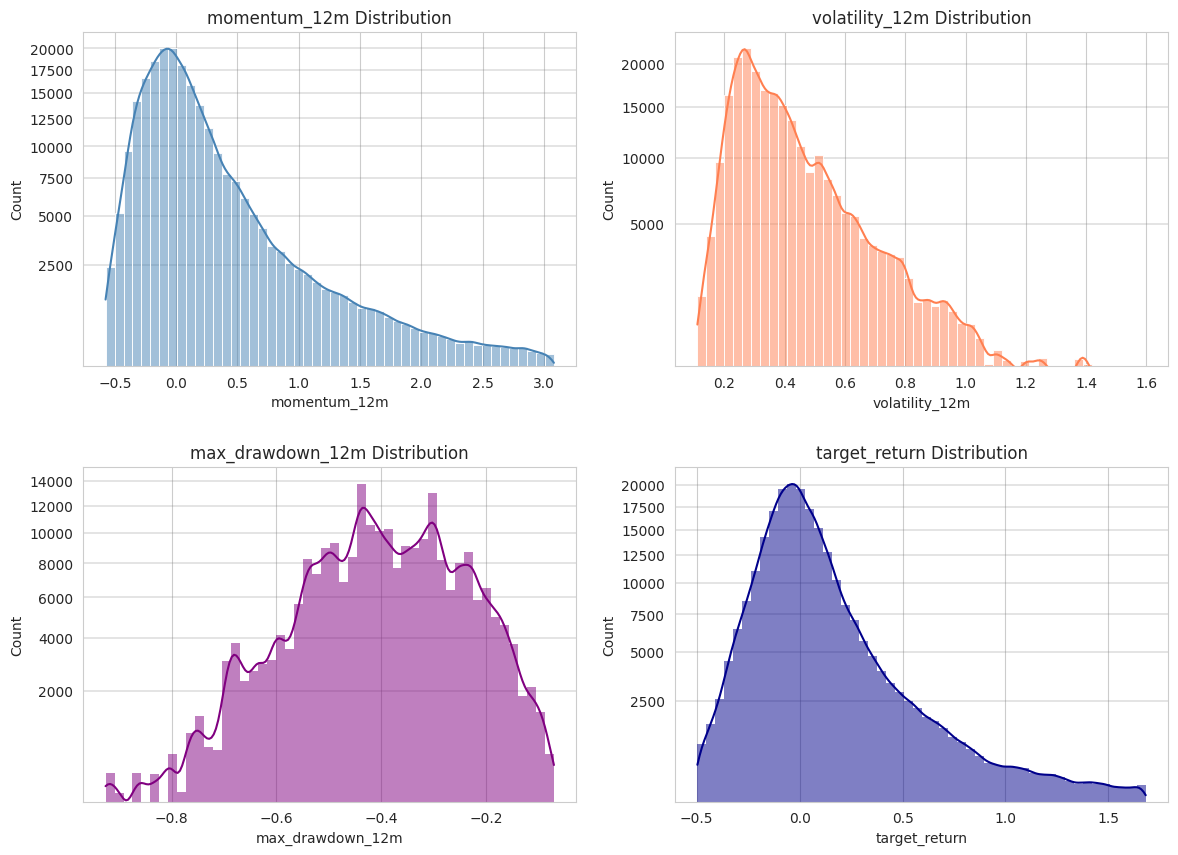

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
data = final_df['momentum_12m'].dropna()
data_clipped = data[(data > data.quantile(0.01)) & (data < data.quantile(0.99))]
ax.set_yscale('function', functions=(np.sqrt, np.square))
ax.grid(axis='y', color='grey', linewidth=0.3)
sns.histplot(data=data_clipped, bins=50, kde=True, ax=ax, color='steelblue')
ax.set_title('momentum_12m Distribution')

ax = axes[0, 1]
ax.set_yscale('function', functions=(np.sqrt, np.square))
ax.grid(axis='y', color='grey', linewidth=0.3)
sns.histplot(data=final_df['volatility_12m'].dropna(), bins=50, kde=True, ax=ax, color='coral')
ax.set_title('volatility_12m Distribution')

ax = axes[1, 0]
ax.set_yscale('function', functions=(np.sqrt, np.square))
ax.grid(axis='y', color='grey', linewidth=0.3)
sns.histplot(data=final_df['max_drawdown_12m'].dropna(), bins=50, kde=True, ax=ax, color='purple')
ax.set_title('max_drawdown_12m Distribution')

ax = axes[1, 1]
ax.set_yscale('function', functions=(np.sqrt, np.square))
ax.grid(axis='y', color='grey', linewidth=0.3)
target_clipped = final_df['target_return'][(final_df['target_return'] > final_df['target_return'].quantile(0.01)) & (final_df['target_return'] < final_df['target_return'].quantile(0.99))]
sns.histplot(data=target_clipped, bins=50, kde=True, ax=ax, color='darkblue')
ax.set_title('target_return Distribution')

fig.subplots_adjust(hspace=0.3)
plt.show()

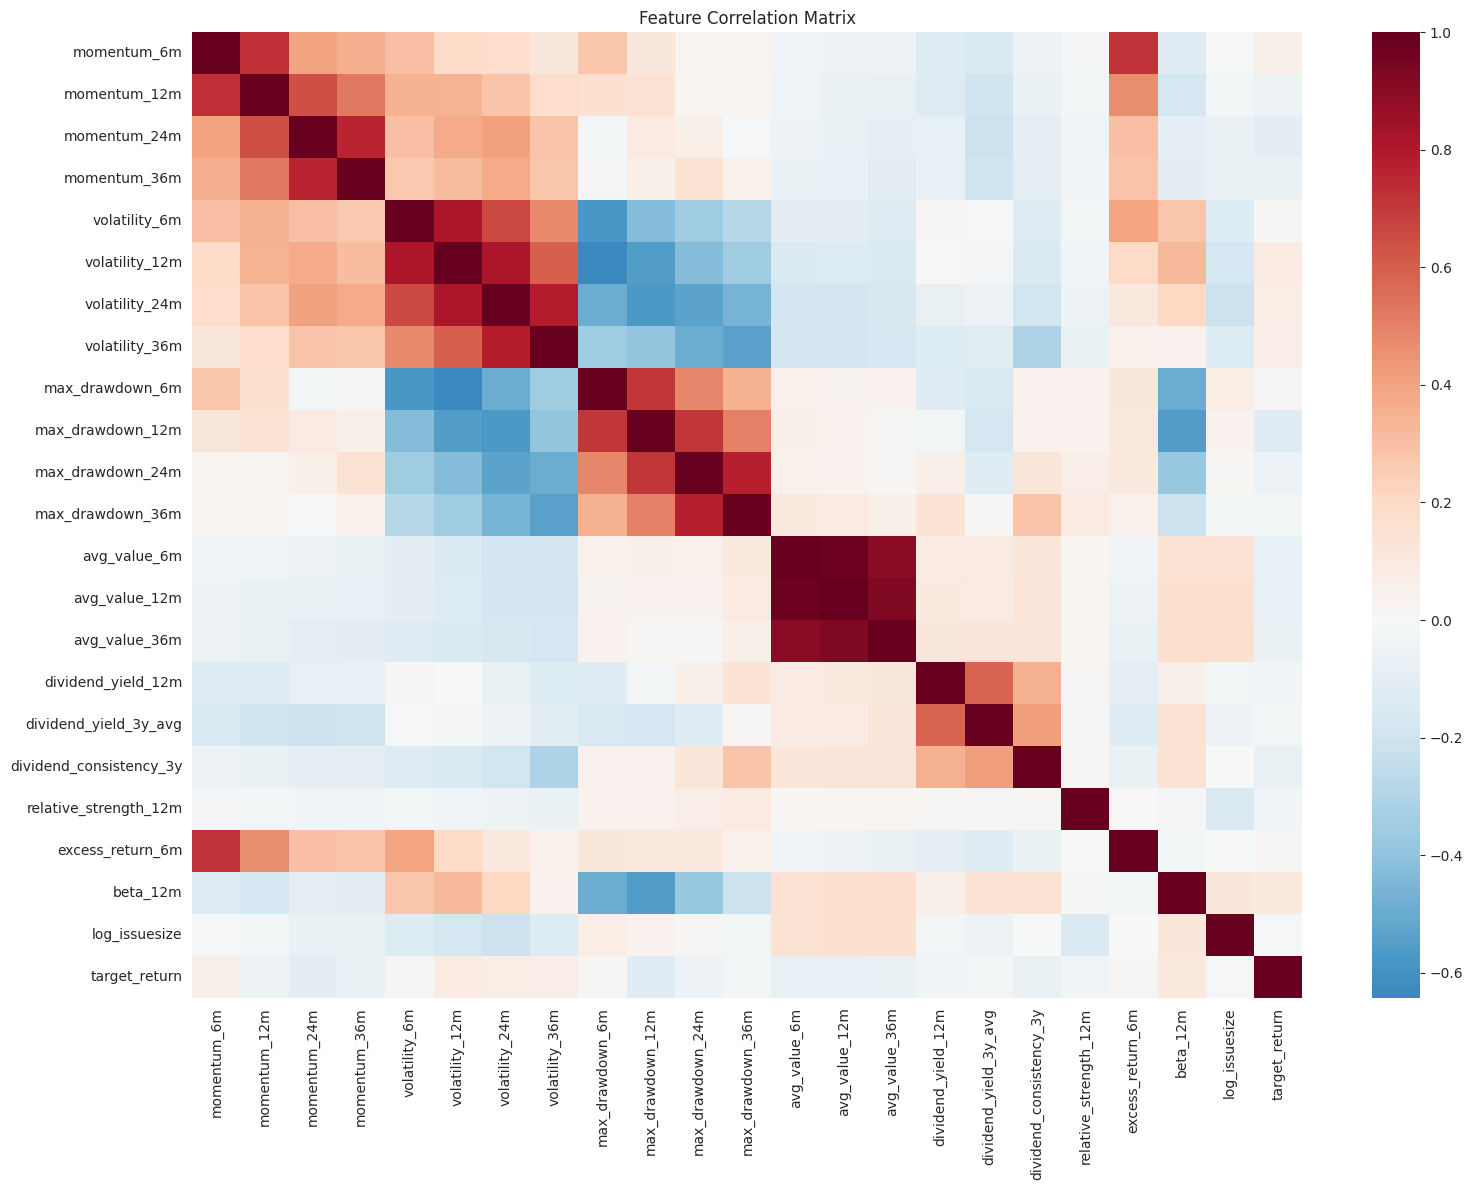

In [14]:
required_features = [
    'momentum_6m', 'momentum_12m', 'momentum_24m', 'momentum_36m',
    'volatility_6m', 'volatility_12m', 'volatility_24m', 'volatility_36m',
    'max_drawdown_6m', 'max_drawdown_12m', 'max_drawdown_24m', 'max_drawdown_36m',
    'avg_value_6m', 'avg_value_12m', 'avg_value_36m',
    'dividend_yield_12m', 'dividend_yield_3y_avg', 'dividend_consistency_3y',
    'relative_strength_12m', 'excess_return_6m', 'beta_12m', 'log_issuesize'
]

feature_cols_all = required_features + ['target_return']
corr = final_df[feature_cols_all].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## **Report**

Files created:
  - market_history_corrected.csv: cleaned raw data
  - features_all.csv: all calculated features
  - final_dataset.csv: final dataset for ML